In [1]:
import pandas as pd
import numpy as np
import joblib, json, pathlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.facecolor': '#22272E', 'axes.facecolor': '#22272E', 'text.color': 'white', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'axes.edgecolor': '#22272E', 'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False, 'axes.spines.bottom': False, 'grid.color': '#32373E'})
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

ENCDM = pd.read_parquet('../Data/Processed/CleanENCDM.parquet')
RGPH = pd.read_parquet('../Data/Processed/CleanRGPH.parquet')

Colors = {'orange' : '#F4583E', 'blue' : '#62C1FE', 'purple' : '#8957E5', 'green' : '#2EA043', 'grey' : '#444C56', 'gold' : '#D29922', 'pink' : '#F92672'}

with open('../Assets/Maps/MapENCDM.json', 'r', encoding = 'utf-8') as file :
    MapENCDM = json.load(file)
    MapENCDM = {column : {code : label for label, code in values.items()} for column, values in MapENCDM.items()}
with open('../Assets/Maps/MapRGPH.json', 'r', encoding = 'utf-8') as file :
    MapRGPH = json.load(file)
    MapRGPH = {column : {code : label for label, code in values.items()} for column, values in MapRGPH.items()}

display(ENCDM.head(5), RGPH.head(5))

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,-1.237737,-1.034735,0.0,0.0,-1.234408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-1.887900,0.0,-1.421570,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,-1.237737,-0.956928,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,-1.178992,1.0,-1.421570,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,-1.237737,-0.956257,0.0,0.0,-0.783824,1.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,1.0,0.0,-1.037211,1.0,0.690091,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,-1.237737,-0.876437,0.0,0.0,-0.783824,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-1.320774,2.0,-1.421570,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,-1.237737,-0.881132,0.0,0.0,-0.333240,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,-0.753648,3.0,0.690091,0.0,2.0,2.0,0.0,1.0,4.0,1.0


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.0,0.0,-0.726056,-1.090852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.11699,0.0,9.999995
1,0.0,0.0,1.0,-0.725987,0.179217,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00000,1.0,9.999995
2,0.0,0.0,1.0,-0.725918,0.179217,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.00000,2.0,9.999995
3,0.0,0.0,1.0,-0.725849,1.025930,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.00000,3.0,9.999995
4,0.0,0.0,1.0,-0.725780,0.179217,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.00000,2.0,9.999995


In [2]:
for scaler in [file.name for file in pathlib.Path('../Models/Scalers/ENCDM/').glob('*')] :
    ENCDM[scaler.removeprefix('SS_').removesuffix('.joblib')] = joblib.load(f'../Models/Scalers/ENCDM/{scaler}').inverse_transform(pd.DataFrame(ENCDM[scaler.removeprefix('SS_').removesuffix('.joblib')]))
for scaler in [file.name for file in pathlib.Path('../Models/Scalers/RGPH/').glob('*')] :
    RGPH[scaler.removeprefix('SS_').removesuffix('.joblib')] = joblib.load(f'../Models/Scalers/RGPH/{scaler}').inverse_transform(pd.DataFrame(RGPH[scaler.removeprefix('SS_').removesuffix('.joblib')]))

display(ENCDM.head(5), RGPH.head(5))

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,165.0,560.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,165.0,676.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,36.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,165.0,677.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,1.0,0.0,38.0,1.0,2.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,165.0,796.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,34.0,2.0,1.0,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,165.0,789.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,42.0,3.0,2.0,0.0,2.0,2.0,0.0,1.0,4.0,1.0


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.11699,0.0,9.999995
1,0.0,0.0,1.0,2.0,5.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00000,1.0,9.999995
2,0.0,0.0,1.0,3.0,5.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.00000,2.0,9.999995
3,0.0,0.0,1.0,4.0,7.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.00000,3.0,9.999995
4,0.0,0.0,1.0,5.0,5.0,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.00000,2.0,9.999995


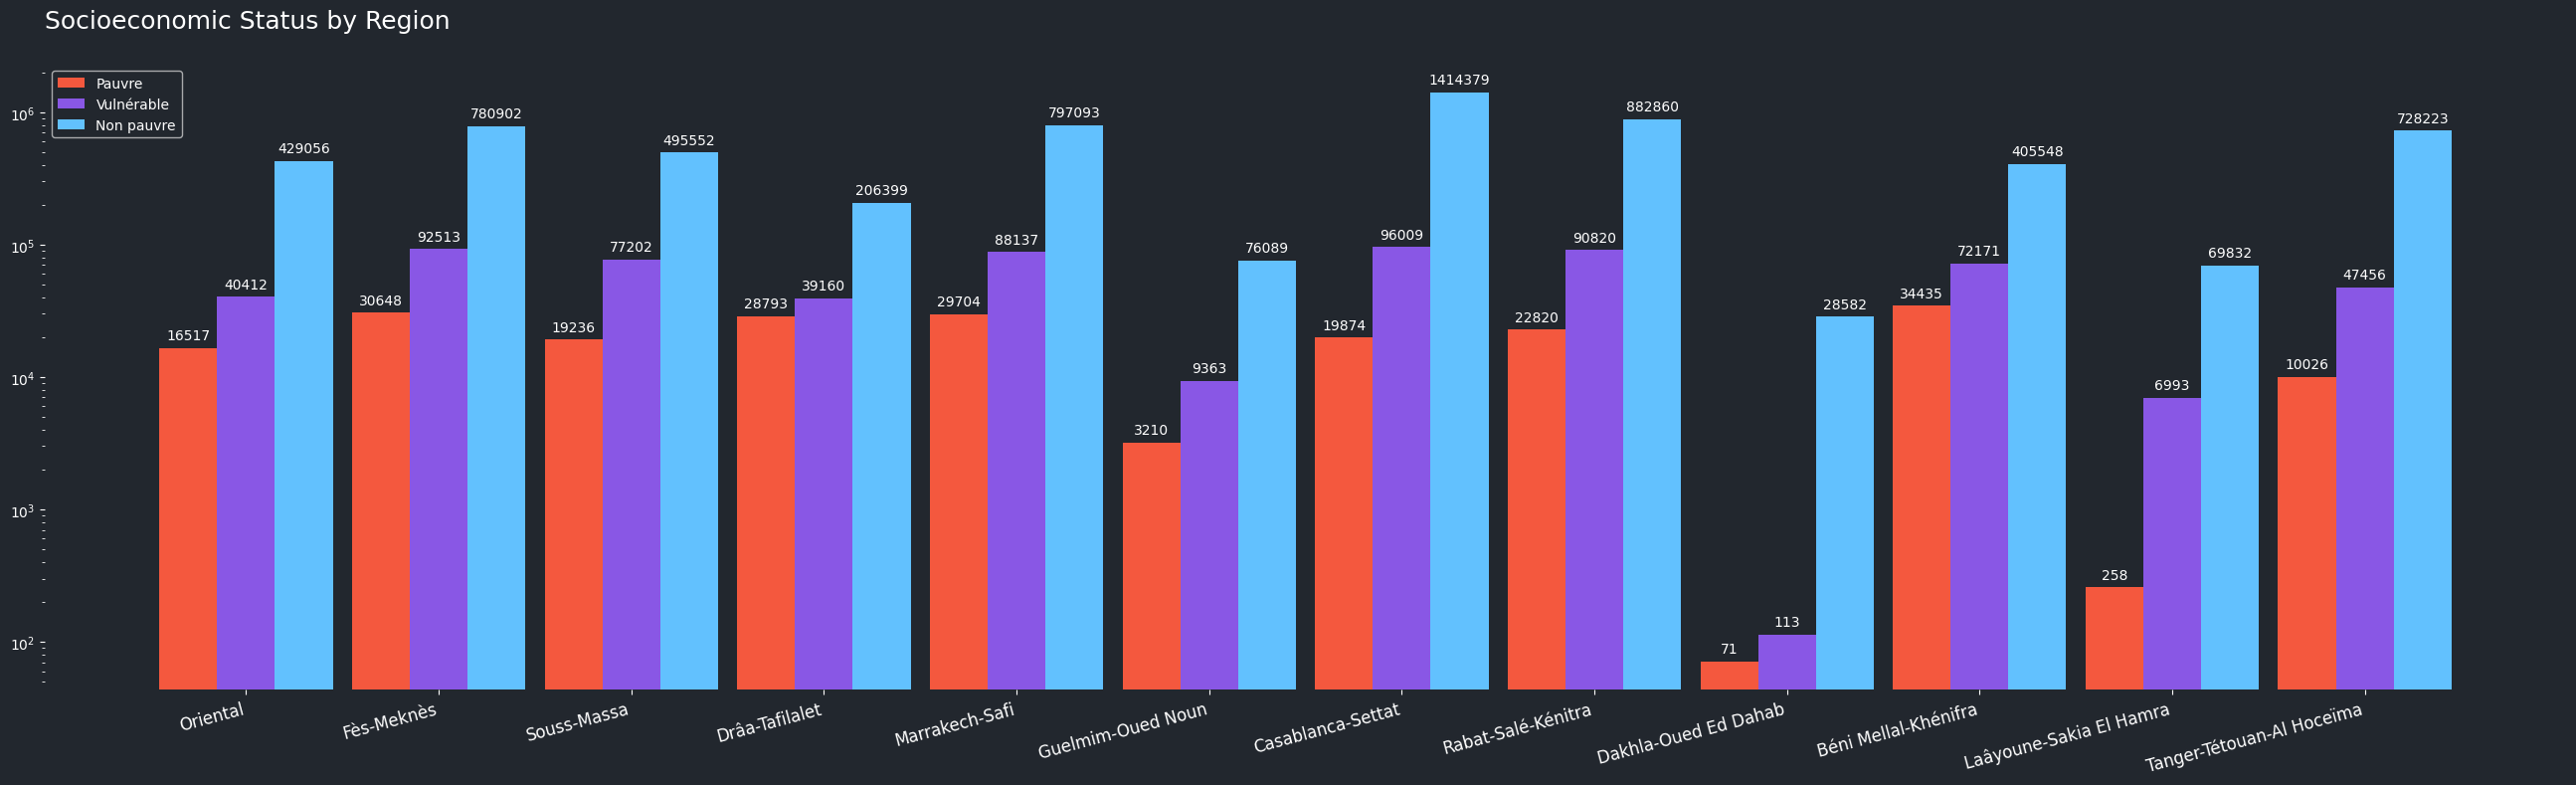

In [43]:
pauverty = {
    MapENCDM['Région_12'][region]: {
        'Non pauvre': ENCDM[(ENCDM['Pauvre'] == 0) & (ENCDM['Vulnérable'] == 0) & (ENCDM['Région_12'] == region)]['coef_ménage'].sum(),
        'Vulnérable': ENCDM[(ENCDM['Pauvre'] == 0) & (ENCDM['Vulnérable'] == 1) & (ENCDM['Région_12'] == region)]['coef_ménage'].sum(),
        'Pauvre': ENCDM[(ENCDM['Pauvre'] == 1) & (ENCDM['Région_12'] == region)]['coef_ménage'].sum()
    } for region in ENCDM['Région_12'].unique()
}
pauverty = {key: value for key, value in sorted(pauverty.items(), key = lambda item : len(item[0]))}

x = np.arange(len(pauverty))
width = 0.3
fig, ax = plt.subplots(figsize = (26, 8))

non_pauvre = [value['Non pauvre'] for value in pauverty.values()]
vulnerable = [value['Vulnérable'] for value in pauverty.values()]
pauvre = [value['Pauvre'] for value in pauverty.values()]

b1 = ax.bar(x - width, pauvre, width, label = 'Pauvre', color = Colors['orange'])
b2 = ax.bar(x, vulnerable, width, label = 'Vulnérable', color = Colors['purple'])
b3 = ax.bar(x + width, non_pauvre, width, label = 'Non pauvre', color = Colors['blue'])

ax.set_yscale('log')
ax.set_title('Socioeconomic Status by Region', loc = 'left', fontsize = 18, pad = 26)
ax.set_xticks(x)
ax.set_xticklabels(list(pauverty.keys()), fontsize = 12, rotation = 15, ha = 'right')
ax.legend()

ax.bar_label(b1, padding = 4, fontsize = 10, fmt = '%.0f')
ax.bar_label(b2, padding = 4, fontsize = 10, fmt = '%.0f')
ax.bar_label(b3, padding = 4, fontsize = 10, fmt = '%.0f')

plt.tight_layout()
plt.show()

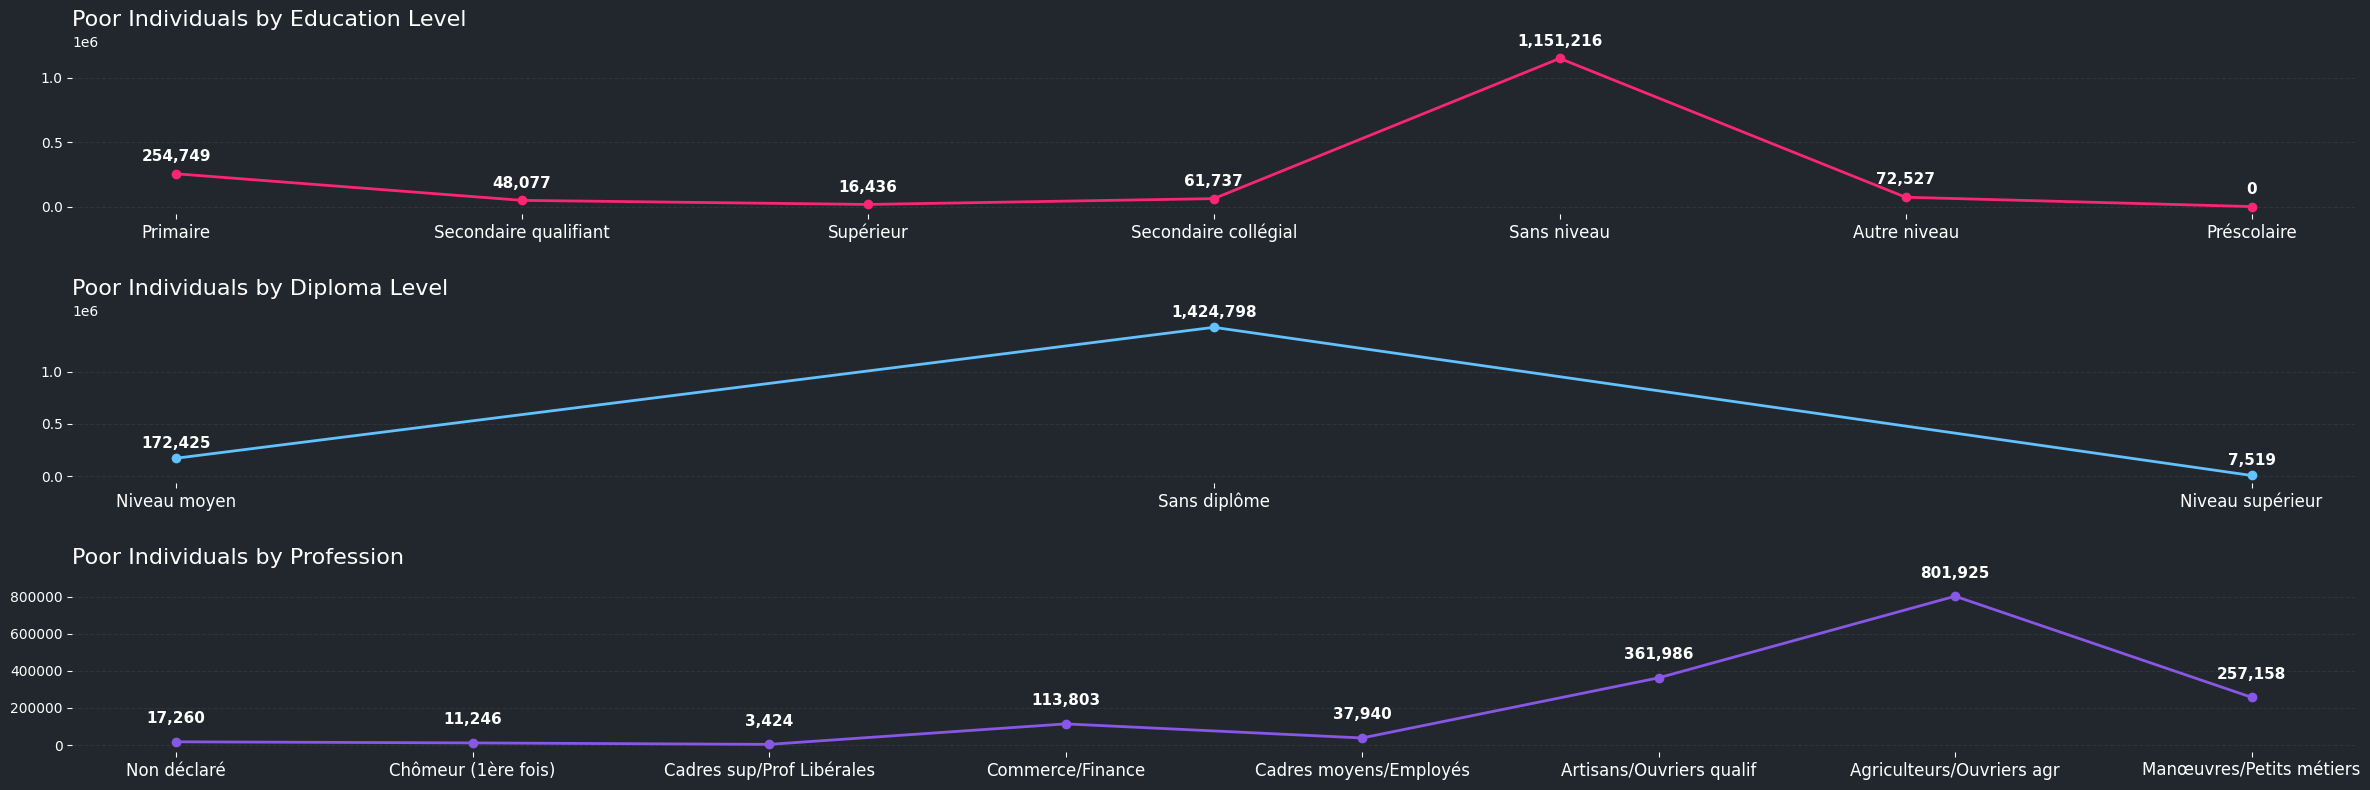

In [44]:
cuts = {"Non déclaré": "Non déclaré","Chômeur n'ayant jamais travaillés": "Chômeur (1ère fois)","Cadres moyens et employés de bureau": "Cadres moyens/Employés","Commerçants, intermédiaires commerciaux  et financiers": "Commerce/Finance","Exploitants et ouvriers agricoles (y compris pêche, chasse et forêt)": "Agriculteurs/Ouvriers agr","Manœuvres non agricoles, manutentionnaires et  travailleurs des petits métiers": "Manœuvres/Petits métiers","Artisans et ouvriers qualifies et conducteurs d'installations et de machines et ouvriers  de l'assemblage": "Artisans/Ouvriers qualif","directeurs et cadres de direction, membres des corps législatifs,cadres supérieurs et membres des professions libérales": "Cadres sup/Prof Libérales"}

niveaux_data = ENCDM.groupby(['Niveau_scolaire_agreg_CM', 'Pauvre'])['coef_indiv'].sum().unstack(fill_value = 0)
labels_niv = [MapENCDM['Niveau_scolaire_agreg_CM'][i] for i in niveaux_data.index]

diplome_data = ENCDM.groupby(['Diplôme_agregé_CM', 'Pauvre'])['coef_indiv'].sum().unstack(fill_value = 0)
labels_dip = [MapENCDM['Diplôme_agregé_CM'][i] for i in diplome_data.index]

profs_data = ENCDM.dropna(subset = ['Profession_agreg_CM']).groupby(['Profession_agreg_CM', 'Pauvre'])['coef_indiv'].sum().unstack(fill_value = 0)
profs_data = profs_data.loc[sorted(profs_data.index, key = lambda x: - int(x))]
labels_prof = [cuts.get(MapENCDM['Profession_agreg_CM'][i], MapENCDM['Profession_agreg_CM'][i]) for i in profs_data.index]

fig, axes = plt.subplots(3, 1, figsize = (24, 8))

for ax in axes : ax.grid(True, axis = 'y', linestyle = '--', alpha = 0.85)

x = np.arange(len(labels_niv))
axes[0].plot(x, niveaux_data[1], color = Colors['pink'], marker = 'o', linewidth = 2)
axes[0].set_title('Poor Individuals by Education Level', fontsize = 16, loc = 'left', pad = 18)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_niv, fontsize = 12)
for i, val in enumerate(niveaux_data[1]): axes[0].text(i, val + 100000, f'{int(val):,}', ha = 'center', fontsize = 11, fontweight = 'bold')

x = np.arange(len(labels_dip))
axes[1].plot(x, diplome_data[1], color = Colors['blue'], marker = 'o', linewidth = 2)
axes[1].set_title('Poor Individuals by Diploma Level', fontsize = 16, loc = 'left', pad = 18)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_dip, fontsize = 12)
for i, val in enumerate(diplome_data[1]): axes[1].text(i, val + 100000, f'{int(val):,}', ha = 'center', fontsize = 11, fontweight = 'bold')

x = np.arange(len(labels_prof))
axes[2].plot(x, profs_data[1], color = Colors['purple'], marker = 'o', linewidth = 2)
axes[2].set_title('Poor Individuals by Profession', fontsize = 16, loc = 'left', pad = 18)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_prof, fontsize = 12)
for i, val in enumerate(profs_data[1]): axes[2].text(i, val + 100000, f'{int(val):,}', ha = 'center', fontsize = 11, fontweight = 'bold')

plt.tight_layout()
fig.subplots_adjust(hspace = 0.65)
plt.show()

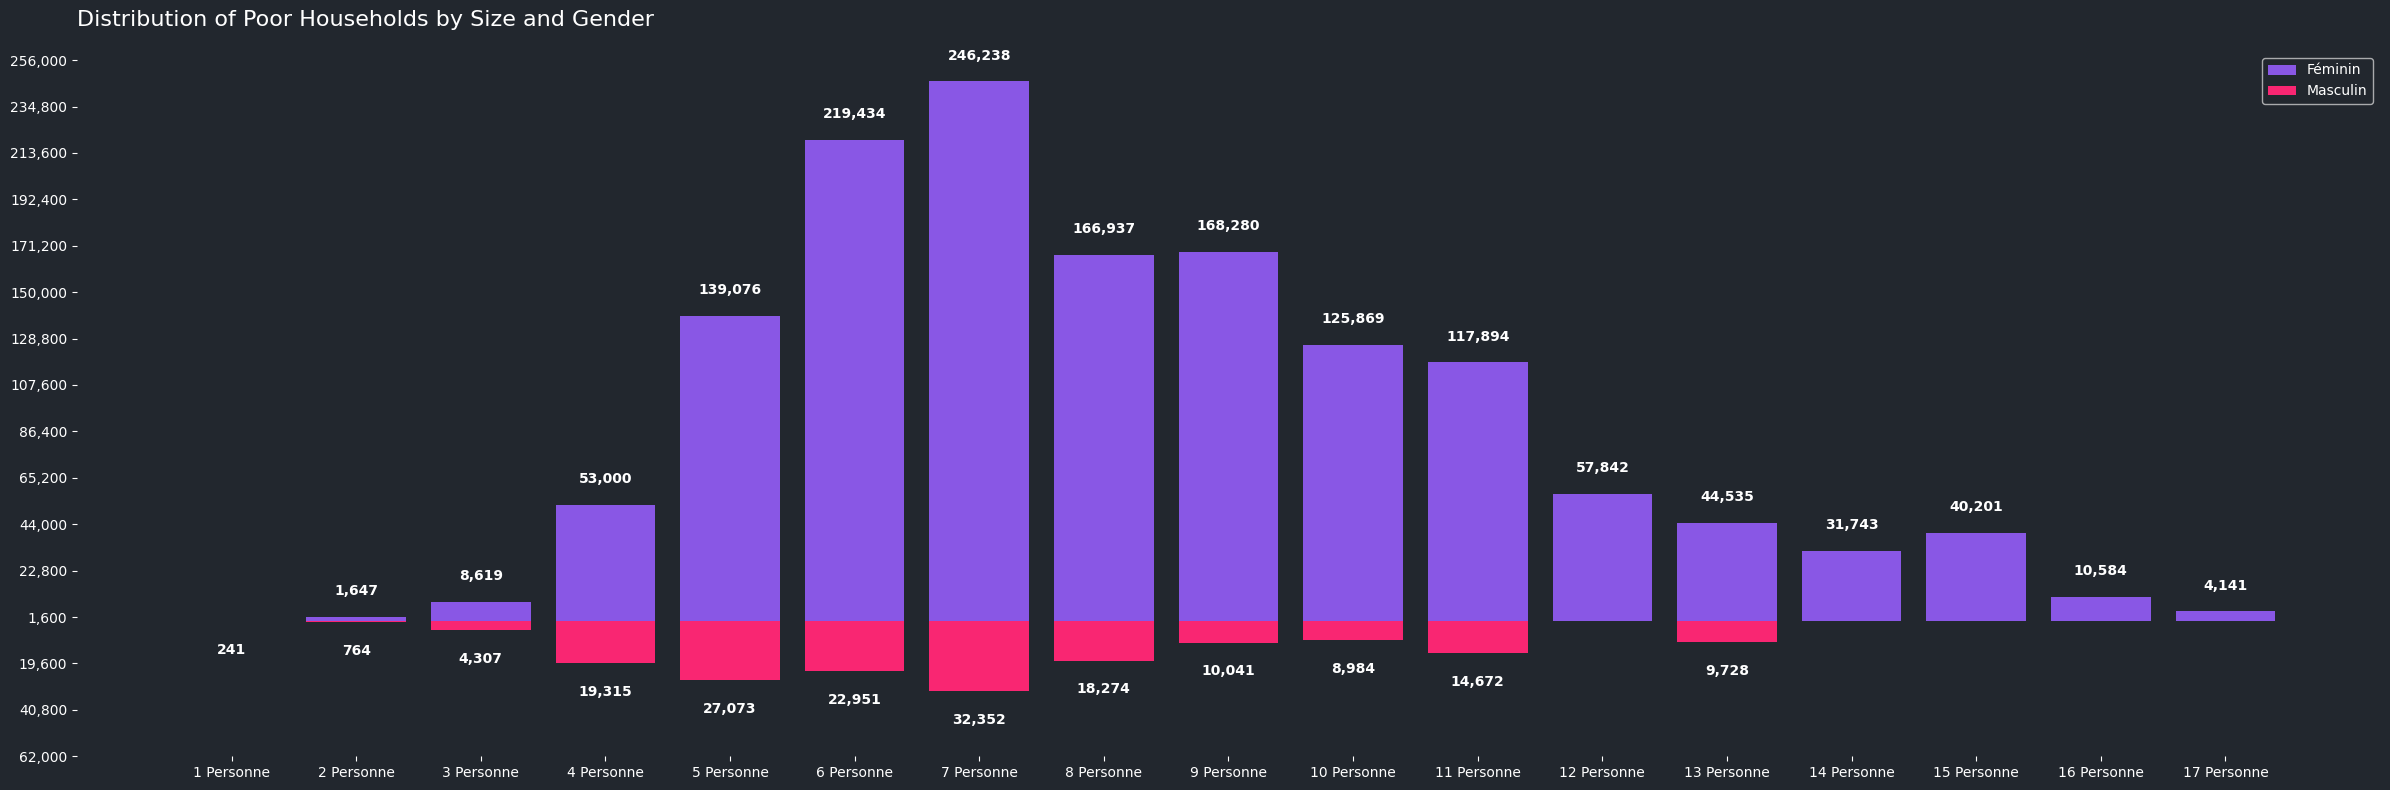

In [61]:
pyramid = ENCDM[ENCDM['Pauvre'] == 1.0].groupby(['Taille_ménage', 'Sexe_CM'])['coef_indiv'].sum().unstack(fill_value = 0)

sizes = pyramid.index
male = pyramid[0]
female = pyramid[1]

fig, ax = plt.subplots(figsize = (24, 8))

ax.bar(sizes, male, color = Colors['purple'], label = MapENCDM['Sexe_CM'][1])
ax.bar(sizes, - female, color = Colors['pink'], label = MapENCDM['Sexe_CM'][0])

ticks = np.linspace(- round(female.max(), -3) - 30000, round(male.max(), -3) + 10000, 16)
ax.set_yscale('linear')
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(abs(t)):,}" for t in ticks])

ax.set_title('Distribution of Poor Households by Size and Gender', fontsize = 16, loc = 'left', pad = 18)
ax.set_xticks(sizes)
ax.set_xticklabels([f"{int(i)} Personne" for i in sizes])
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.axhline(0, color = 'none') 

for i, val in enumerate(female) :
    if val > 0 : ax.text(sizes[i], - val - 15000, f'{int(val):,}', ha = 'center', fontweight = 'bold', fontsize = 10)
for i, val in enumerate(male) :
    if val > 0 : ax.text(sizes[i], + val + 10000, f'{int(val):,}', ha = 'center', fontweight = 'bold', fontsize = 10)

plt.tight_layout()
plt.show()